# Figure 4: Simulation study for distributional treatment-effect prediction

This notebook reproduces **Figure 4** in the paper.

The output reports the Maximum Mean Discrepancy (MMD) between the true and estimated counterfactual distributions as a function of the number of untreated units \(J\), for several choices of the moment order \(G\).

## How to run

Run all cells from top to bottom. The main simulation cell loops over the grid of \(J\) values used in the paper and repeats the experiment across multiple trials.

## Notes

- The final plot corresponds to Figure 4 in the paper.
- Intermediate arrays can be saved from the notebook if you would like to reuse the simulated results without rerunning the full experiment.


In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mmscm import *

from scipy.stats import gaussian_kde

In [3]:
import torch
%matplotlib inline
from matplotlib import pyplot
import tqdm

In [4]:
def mmd(x, y, sigma):
    # compare kernel MMD paper and code:
    # A. Gretton et al.: A kernel two-sample test, JMLR 13 (2012)
    # http://www.gatsby.ucl.ac.uk/~gretton/mmd/mmd.htm
    # x shape [n, d] y shape [m, d]
    # n_perm number of bootstrap permutations to get p-value, pass none to not get p-value
    n, d = x.shape
    m, d2 = y.shape
    assert d == d2
    xy = torch.cat([x.detach(), y.detach()], dim=0)
    dists = torch.cdist(xy, xy, p=2.0)
    # we are a bit sloppy here as we just keep the diagonal and everything twice
    # note that sigma should be squared in the RBF to match the Gretton et al heuristic
    k = torch.exp((-1/(2*sigma**2)) * dists**2) + torch.eye(n+m)*1e-5
    k_x = k[:n, :n]
    k_y = k[n:, n:]
    k_xy = k[:n, n:]
    # The diagonals are always 1 (up to numerical error, this is (3) in Gretton et al.)
    # note that their code uses the biased (and differently scaled mmd)
    mmd = k_x.sum() / (n * (n - 1)) + k_y.sum() / (m * (m - 1)) - 2 * k_xy.sum() / (n * m)
    return mmd

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [32]:
np.random.seed(0)

total_period = 1050
intervention = 50
target_year = intervention

dim = 5
max_sample_size = 1

target_unit_var = 1
target_unit = "-1"
target_year_var = 0

target_outcome_var = 2

treatment_effect = 20

abadie_res_list = []
abadie_res_list2 = []
abadie_res_list3 = []
abadie_res_list5 = []
abadie_res_list10 = []
abadie_res_list50 = []
abadie_res_list100 = []
discoscm_pred_list = []
ATE_list = []

set_units = [5*i for i in range(1, 11)]

for num_untreatment_units in set_units:
    print("num_untreatment_units", num_untreatment_units)
    
    abadie_res_list_temp = []
    abadie_res_list2_temp = []
    abadie_res_list3_temp = []
    abadie_res_list5_temp = []
    abadie_res_list10_temp = []
    abadie_res_list50_temp = []
    abadie_res_list100_temp = []
    discoscm_pred_list_temp = []
    ATE_list_temp = []

    for trial in range(100):
        print("trial", trial)

        means = np.random.normal(size=(num_untreatment_units, dim))
        variances = np.random.uniform(1, 20, size=(num_untreatment_units, dim))
        params = np.random.uniform(0, 1, size=(num_untreatment_units, 1))
        params = params/np.sum(params)

        sample_sizes = np.array(np.random.uniform(1, max_sample_size, size=(num_untreatment_units+1, total_period)), np.int64)

        treated_mean = means.T.dot(params).T
        treated_variance = variances.T.dot(params).T

        count = 0

        data = []

        for t in range(total_period):

            for i in range(-1, num_untreatment_units):
                temp_data = []

                if i == -1:
                    temp_data2 = []

                    for s in range(sample_sizes[i, t]):
                        if (t + 1) > intervention:
                            choice_idx = np.random.choice([i for i in range(num_untreatment_units)], p=params.T[0])
                            temp = (np.random.multivariate_normal(means[choice_idx], np.diag(variances[choice_idx]), size=1))[0]
                            temp[0] = temp[0] + treatment_effect
                            temp_data2.append(temp)
                        else:
                            choice_idx = np.random.choice([i for i in range(num_untreatment_units)], p=params.T[0])
                            temp_data2.append((np.random.multivariate_normal(means[choice_idx], np.diag(variances[choice_idx]), size=1))[0])

                    temp_data = np.array(temp_data2)[0]
                else:
                    temp_data = (np.random.multivariate_normal(means[i], np.diag(variances[i]), size=sample_sizes[i, t]))[0]

                temp_data = [t+1, "%d"%i] + list(temp_data)
                if count == 0:
                    data = pd.DataFrame(temp_data).T
                    count += 1
                else:
                    data_temp = pd.DataFrame(temp_data).T
                    data = pd.concat([data, data_temp])


                means[:, 0] +=  np.random.normal(0, 10, size=means.shape[0])
                variances[:, 0] +=  np.random.normal(0, 10, size=variances.shape[0])

                variances[variances < 0.1] = 0.1


            #data.append(temp_data)

        data = data[data[1] != "2"]

        abadiescm = MMSCM(data, "Abadie", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year)
        abadiescm.train_param()
        orignal_val, abadiescm_pred = abadiescm.dist_infernece()
        original_val, abadiescm_pred_mean = abadiescm.predict(bias=True)
        abadiescm_pred_mean = (original_val - abadiescm_pred_mean)[intervention + 1]
        
        sub_data = data.copy()
        unit_names = sub_data[target_unit_var].unique()

        for u in unit_names:
            temp_data = sub_data[(sub_data[target_unit_var] == u) & (sub_data[target_year_var] <= target_year)]
            target_outcome_varues = temp_data[target_outcome_var]
            mean_val = np.mean(target_outcome_varues)
            if u == target_unit:
                target_mean_val = mean_val
            sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var] = sub_data.loc[sub_data[target_unit_var] == u, target_outcome_var]  - mean_val

        fpscm = MMSCM(sub_data, "Abadie", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year)
        fpscm.train_param()
        _, fpscm_pred = fpscm.predict(bias=False)
        fpscm_pred = fpscm_pred + target_mean_val
        fpscm_pred_mean = (original_val - fpscm_pred)[intervention + 1]




        abadiescm2 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=2)
        abadiescm2.train_param()
        orignal_val, abadiescm_pred2 = abadiescm2.dist_infernece()
        orignal_val, abadiescm2_pred_mean = abadiescm2.predict(bias=True)
        abadiescm2_pred_mean = (orignal_val - abadiescm2_pred_mean)[intervention + 1]

        abadiescm3 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=3)
        abadiescm3.train_param()
        orignal_val, abadiescm_pred3 = abadiescm3.dist_infernece()
        orignal_val, abadiescm3_pred_mean = abadiescm3.predict(bias=True)
        abadiescm3_pred_mean = (orignal_val - abadiescm3_pred_mean)[intervention + 1]

        abadiescm5 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=5)
        abadiescm5.train_param()
        orignal_val, abadiescm_pred5 = abadiescm5.dist_infernece()
        orignal_val, abadiescm5_pred_mean = abadiescm5.predict(bias=True)
        abadiescm5_pred_mean = (orignal_val - abadiescm5_pred_mean)[intervention + 1]

        abadiescm10 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=10)
        abadiescm10.train_param()
        orignal_val, abadiescm_pred10 = abadiescm10.dist_infernece()
        orignal_val, abadiescm10_pred_mean = abadiescm10.predict(bias=True)
        abadiescm10_pred_mean = (orignal_val - abadiescm10_pred_mean)[intervention + 1]
        
        abadiescm50 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=50)
        abadiescm50.train_param()
        orignal_val, abadiescm_pred50 = abadiescm50.dist_infernece()
        orignal_val, abadiescm50_pred_mean = abadiescm50.predict(bias=True)
        abadiescm50_pred_mean = (orignal_val - abadiescm50_pred_mean)[intervention + 1]
        
        abadiescm100 = MMSCM(data, "MMSCM", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year, poly=100)
        abadiescm100.train_param()
        orignal_val, abadiescm_pred100 = abadiescm100.dist_infernece()
        orignal_val, abadiescm100_pred_mean = abadiescm100.predict(bias=True)
        abadiescm100_pred_mean = (orignal_val - abadiescm100_pred_mean)[intervention + 1]
        
        discoscm = MMSCM(data, "DiSCo", target_unit_var, target_unit, target_outcome_var, target_year_var, target_year)
        discoscm.train_param()
        orignal_val, discoscm_pred = discoscm.dist_infernece()
        orignal_val, discoscm_pred_mean = discoscm.predict(bias=True)
        discoscm_pred_mean = (orignal_val - discoscm_pred_mean)[intervention + 1]
        
        orignal_val = torch.FloatTensor(np.array(orignal_val, np.float64))
        all_data = list(orignal_val) + abadiescm_pred + abadiescm_pred2 + abadiescm_pred3 + abadiescm_pred5 + abadiescm_pred10
        all_data = torch.FloatTensor(all_data)

        abadiescm_pred = torch.FloatTensor(np.array(abadiescm_pred, np.float64))
        abadiescm_pred2= torch.FloatTensor(np.array(abadiescm_pred2, np.float64))
        abadiescm_pred3 = torch.FloatTensor(np.array(abadiescm_pred3, np.float64))
        abadiescm_pred5 = torch.FloatTensor(np.array(abadiescm_pred5, np.float64))
        abadiescm_pred10 = torch.FloatTensor(np.array(abadiescm_pred10, np.float64))
        abadiescm_pred50 = torch.FloatTensor(np.array(abadiescm_pred50, np.float64))
        abadiescm_pred100 = torch.FloatTensor(np.array(abadiescm_pred100, np.float64))
        discoscm_pred = torch.FloatTensor(np.array(discoscm_pred, np.float64))
        
        dists = torch.pdist(torch.cat([orignal_val, all_data], dim=0)[:,None])
        sigma = dists[:100].median()/2

        ##########################################


        our_mmd = mmd(orignal_val[:, None], abadiescm_pred[:, None], sigma)
        abadie_res_list_temp.append(our_mmd.data.numpy())

        our_mmd = mmd(orignal_val[:, None], abadiescm_pred2[:, None], sigma)
        abadie_res_list2_temp.append(our_mmd.data.numpy())
        
        our_mmd = mmd(orignal_val[:, None], abadiescm_pred3[:, None], sigma)
        abadie_res_list3_temp.append(our_mmd.data.numpy())
        
        our_mmd = mmd(orignal_val[:, None], abadiescm_pred5[:, None], sigma)
        abadie_res_list5_temp.append(our_mmd.data.numpy())
        
        our_mmd = mmd(orignal_val[:, None], abadiescm_pred10[:, None], sigma)
        abadie_res_list10_temp.append(our_mmd.data.numpy())
        
        our_mmd = mmd(orignal_val[:, None], abadiescm_pred50[:, None], sigma)
        abadie_res_list50_temp.append(our_mmd.data.numpy())
        
        our_mmd = mmd(orignal_val[:, None], abadiescm_pred100[:, None], sigma)
        abadie_res_list100_temp.append(our_mmd.data.numpy())
        
        our_mmd = mmd(orignal_val[:, None], discoscm_pred[:, None], sigma)
        discoscm_pred_list_temp.append(our_mmd.data.numpy())
        
        ATE_list_temp.append([abadiescm2_pred_mean, abadiescm3_pred_mean, abadiescm5_pred_mean, abadiescm10_pred_mean, abadiescm50_pred_mean, abadiescm100_pred_mean, abadiescm_pred_mean, fpscm_pred_mean, discoscm_pred_mean])
        
    
    abadie_res_list2.append(abadie_res_list2_temp)
    abadie_res_list3.append(abadie_res_list3_temp)
    abadie_res_list5.append(abadie_res_list5_temp)
    abadie_res_list10.append(abadie_res_list10_temp)
    abadie_res_list50.append(abadie_res_list50_temp)
    abadie_res_list100.append(abadie_res_list100_temp)
    abadie_res_list.append(abadie_res_list_temp)
    discoscm_pred_list.append(discoscm_pred_list_temp)
    ATE_list.append(ATE_list_temp)

num_untreatment_units 5
trial 0
trial 1
trial 2
trial 3
trial 4
trial 5
trial 6
trial 7
trial 8
trial 9
trial 10
trial 11
trial 12
trial 13
trial 14
trial 15
trial 16
trial 17
trial 18
trial 19
trial 20
trial 21
trial 22
trial 23
trial 24
trial 25
trial 26
trial 27
trial 28
trial 29
trial 30
trial 31
trial 32
trial 33
trial 34
trial 35
trial 36
trial 37
trial 38
trial 39
trial 40
trial 41
trial 42
trial 43
trial 44
trial 45
trial 46
trial 47
trial 48
trial 49
trial 50
trial 51
trial 52
trial 53
trial 54
trial 55
trial 56
trial 57
trial 58
trial 59
trial 60
trial 61
trial 62
trial 63
trial 64
trial 65
trial 66
trial 67
trial 68
trial 69
trial 70
trial 71
trial 72
trial 73
trial 74
trial 75
trial 76
trial 77
trial 78
trial 79
trial 80
trial 81
trial 82
trial 83
trial 84
trial 85
trial 86
trial 87
trial 88
trial 89
trial 90
trial 91
trial 92
trial 93
trial 94
trial 95
trial 96
trial 97
trial 98
trial 99
num_untreatment_units 10
trial 0
trial 1
trial 2
trial 3
trial 4
trial 5
trial 6
trial

KeyboardInterrupt: 

KeyboardInterrupt: 

## Saved intermediate arrays

This notebook includes commands for saving intermediate NumPy arrays from the simulation. These saved arrays are optional and are only used for convenience when reusing the simulation output.


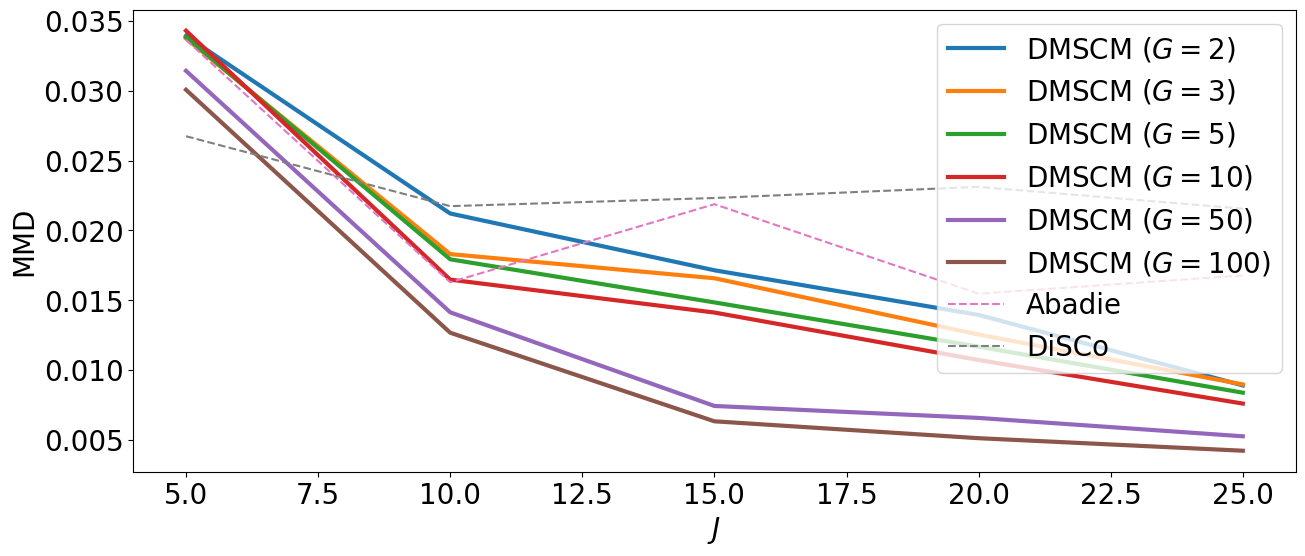

In [31]:
length = 11

plt.figure(figsize=(15,6))

plt.plot(set_units[:length], np.array(abadie_res_list2)[:length].mean(axis=1), label="DMSCM ($G=2$)", linewidth=3)
plt.plot(set_units[:length], np.array(abadie_res_list3)[:length].mean(axis=1), label="DMSCM ($G=3$)", linewidth=3)
plt.plot(set_units[:length], np.array(abadie_res_list5)[:length].mean(axis=1), label="DMSCM ($G=5$)", linewidth=3)
plt.plot(set_units[:length], np.array(abadie_res_list10)[:length].mean(axis=1), label="DMSCM ($G=10$)", linewidth=3)
plt.plot(set_units[:length], np.array(abadie_res_list50)[:length].mean(axis=1), label="DMSCM ($G=50$)", linewidth=3)
plt.plot(set_units[:length], np.array(abadie_res_list100)[:length].mean(axis=1), label="DMSCM ($G=100$)", linewidth=3)
plt.plot(set_units[:length], np.array(abadie_res_list)[:length].mean(axis=1), label="Abadie", linestyle='--')
plt.plot(set_units[:length], np.array(discoscm_pred_list)[:length].mean(axis=1) / 1.5, label="DiSCo", linestyle='--')


plt.xticks(size = 20)
plt.yticks(size = 20)

plt.ylabel("MMD", fontsize = 20)
plt.xlabel("$J$", fontsize = 20)


plt.legend(fontsize = 20)
plt.show()